# imports

In [1]:
import pandas as pd
import seaborn as sns

## pull data

In [43]:
path = r'C:\Users\Magsihim_AI\Desktop\Project_Statbotics\data\datasets\full_table2.csv'

df = pd.read_csv(path)

In [3]:
df

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red
1,1.742058e+09,f,2025alhu,2025alhu_f1m2,2,1.742058e+09,1,1.742057e+09,"[{'key': '1FpcfKgS3kw', 'type': 'youtube'}]",blue,...,True,True,True,False,0.0,0.0,frc2783,144.0,1,red
2,1.741960e+09,qm,2025alhu,2025alhu_qm1,1,1.741960e+09,1,1.741960e+09,"[{'key': 'mAbsfvQlhaw', 'type': 'youtube'}]",red,...,False,False,False,False,5.0,2.0,frc5045,129.0,1,red
3,1.741965e+09,qm,2025alhu,2025alhu_qm10,10,1.741965e+09,1,1.741965e+09,"[{'key': 'xrkAU-qZY-E', 'type': 'youtube'}]",red,...,True,True,True,True,1.0,0.0,frc538,112.0,1,red
4,1.741965e+09,qm,2025alhu,2025alhu_qm11,11,1.741965e+09,1,1.741965e+09,"[{'key': 'ae-lJ4geVPg', 'type': 'youtube'}]",blue,...,False,True,True,True,1.0,1.0,frc6107,61.0,1,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116377,1.752379e+09,sf,2025xxmel,2025xxmel_sf5m1,1,1.752379e+09,5,1.752378e+09,[],red,...,False,False,False,False,6.0,0.0,frc9995,64.0,3,blue
116378,1.752379e+09,sf,2025xxmel,2025xxmel_sf6m1,1,1.752379e+09,6,1.752379e+09,[],blue,...,False,False,False,False,1.0,0.0,frc9991,72.0,3,blue
116379,1.752380e+09,sf,2025xxmel,2025xxmel_sf7m1,1,1.752380e+09,7,1.752380e+09,[],red,...,False,False,False,False,0.0,0.0,frc9994,65.0,3,blue
116380,1.752380e+09,sf,2025xxmel,2025xxmel_sf8m1,1,1.752380e+09,8,1.752381e+09,[],red,...,False,True,True,True,14.0,0.0,frc9993,73.0,3,blue


# sum data

In [4]:
df.head(1)

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red


In [5]:
df['autoLine'] = df['autoLine'].map({'Yes': True, 'No': False})

In [6]:
num_bool_cols = ['score', 'autoLine', 'autoReef_tba_botRowCount', 'autoReef_tba_midRowCount', 'autoReef_tba_topRowCount', 'autoReef_trough', 'foulCount', 'netAlgaeCount', 'techFoulCount', 'teleopReef_tba_botRowCount', 'teleopReef_tba_midRowCount', 'teleopReef_tba_topRowCount', 'teleopReef_trough', 'wallAlgaeCount']
cat_cols = ['endGame', 'possition']

In [26]:
sdf = pd.DataFrame()
for team in df['team_number'].unique():
    for col in num_bool_cols:
        # print(col)
        sdf.loc[team, col] = df.loc[df['team_number'] == team, col].mean()
    for col2 in cat_cols:
        sdf.loc[team, col2] = df.loc[df['team_number'] == team, col2].mode().iloc[0]
    sdf['games'] = df.groupby('team_number')['key'].unique()

In [27]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games
frc2783,139.357143,1.000000,0.000000,0.023810,3.500000,0.214286,0.285714,2.309524,0.261905,3.166667,5.976190,9.785714,1.119048,1.428571,DeepCage,1.0,"[2025alhu_f1m1, 2025alhu_f1m2, 2025alhu_qm35, ..."
frc5045,85.000000,0.909091,0.000000,0.136364,1.000000,0.727273,0.318182,1.363636,0.409091,1.000000,2.636364,5.545455,2.863636,1.500000,Parked,1.0,"[2025alhu_qm1, 2025alhu_qm16, 2025tnkn_qm1, 20..."
frc538,78.238095,0.809524,0.095238,0.047619,1.000000,0.238095,0.190476,1.523810,0.333333,1.476190,2.238095,5.333333,1.761905,1.190476,Parked,3.0,"[2025alhu_qm10, 2025alhu_qm21, 2025tnkn_qm21, ..."
frc6107,81.714286,0.952381,0.285714,0.142857,0.666667,0.523810,0.095238,1.857143,0.238095,2.142857,2.952381,3.904762,1.523810,1.809524,Parked,1.0,"[2025alhu_qm11, 2025alhu_qm26, 2025alhu_qm34, ..."
frc8624,50.909091,0.818182,0.000000,0.000000,0.272727,0.000000,0.000000,1.363636,1.454545,1.090909,0.727273,2.636364,1.454545,0.454545,Parked,2.0,"[2025alhu_qm12, 2025alhu_qm75, 2025alhu_qm42, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc7086,74.666667,1.000000,0.083333,0.000000,1.083333,0.083333,0.833333,0.416667,0.250000,3.083333,2.833333,5.416667,1.666667,0.166667,Parked,2.0,"[2025tuis3_qm21, 2025tuis3_sf12m1, 2025tuis3_q..."
frc10180,69.200000,1.000000,0.000000,0.000000,0.400000,0.400000,0.200000,0.700000,2.000000,1.000000,1.000000,1.800000,3.500000,2.900000,DeepCage,2.0,"[2025tuis3_qm27, 2025tuis3_qm59, 2025tuis3_sf5..."
frc4972,49.100000,0.800000,0.000000,0.000000,0.400000,0.500000,0.200000,0.100000,0.700000,0.900000,0.500000,4.500000,2.600000,0.000000,Parked,2.0,"[2025tuis3_qm37, 2025tuis3_qm67, 2025tuis3_qm7..."
frc8500,44.000000,0.500000,0.000000,0.000000,0.375000,0.250000,0.750000,0.375000,0.500000,0.750000,1.125000,2.125000,2.125000,0.000000,Nothing,2.0,"[2025tuis3_qm39, 2025tuis3_qm44, 2025tuis3_qm1..."


In [28]:
sdf.loc['frc1574']

score                                                                129.340426
autoLine                                                                    1.0
autoReef_tba_botRowCount                                               0.021277
autoReef_tba_midRowCount                                               0.042553
autoReef_tba_topRowCount                                               3.531915
autoReef_trough                                                        0.319149
foulCount                                                              0.340426
netAlgaeCount                                                          1.638298
techFoulCount                                                          0.340426
teleopReef_tba_botRowCount                                             3.468085
teleopReef_tba_midRowCount                                             6.021277
teleopReef_tba_topRowCount                                             9.829787
teleopReef_trough                       

In [29]:
sdf.loc['frc1323']

score                                                                233.910714
autoLine                                                                    1.0
autoReef_tba_botRowCount                                               0.553571
autoReef_tba_midRowCount                                                    0.0
autoReef_tba_topRowCount                                               6.053571
autoReef_trough                                                        0.178571
foulCount                                                              0.267857
netAlgaeCount                                                             6.625
techFoulCount                                                          0.160714
teleopReef_tba_botRowCount                                             9.803571
teleopReef_tba_midRowCount                                            10.642857
teleopReef_tba_topRowCount                                            11.660714
teleopReef_trough                       

In [30]:
sdf.sort_values(by='score', ascending=False)

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games
frc1323,233.910714,1.000000,0.553571,0.000000,6.053571,0.178571,0.267857,6.625000,0.160714,9.803571,10.642857,11.660714,9.553571,1.089286,DeepCage,2.0,"[2025capt_qm37, 2025casj_f1m1, 2025casj_f1m2, ..."
frc2056,229.741573,1.000000,0.033708,0.292135,6.292135,0.191011,0.640449,7.741573,0.348315,9.730337,10.955056,11.404494,7.808989,1.056180,DeepCage,1.0,"[2025cmptx_sf4m1, 2025dal_qm91, 2025iri_qm47, ..."
frc2910,217.232877,1.000000,0.342466,0.849315,4.616438,0.287671,0.068493,5.424658,0.315068,9.383562,10.479452,11.191781,7.726027,1.178082,DeepCage,1.0,"[2025cmptx_sf11m1, 2025cmptx_sf13m1, 2025cmptx..."
frc1690,216.870588,1.000000,0.047059,0.082353,6.235294,0.258824,0.482353,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,DeepCage,2.0,"[2025iri_qm71, 2025iscmp_qm26, 2025iscmp_qm8, ..."
frc3276,206.904110,0.972603,0.054795,0.027397,3.780822,0.301370,0.178082,6.410959,0.273973,7.753425,10.000000,11.356164,5.109589,0.904110,DeepCage,2.0,"[2025iri_qm16, 2025iri_qm33, 2025mnmi2_f1m1, 2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc9185,32.875000,0.625000,0.000000,0.000000,0.125000,0.250000,0.750000,0.625000,6.000000,0.625000,0.375000,1.250000,1.000000,0.000000,Parked,1.0,"[2025tuis3_qm17, 2025tuis3_qm25, 2025tuis3_qm3..."
frc10531,32.111111,0.555556,0.111111,0.000000,0.111111,0.111111,1.333333,0.000000,2.000000,1.444444,0.666667,1.333333,0.555556,0.444444,Parked,1.0,"[2025tuis2_qm14, 2025tuis2_qm34, 2025tuis2_qm7..."
frc8898,32.000000,0.200000,0.000000,0.000000,0.000000,0.200000,0.400000,0.500000,0.700000,0.300000,0.800000,1.000000,4.200000,0.400000,Parked,2.0,"[2025cala_qm11, 2025cala_qm24, 2025cala_qm46, ..."
frc9675,30.500000,0.750000,0.000000,0.000000,0.125000,0.250000,0.250000,0.750000,0.250000,0.125000,0.750000,1.375000,2.000000,0.000000,Parked,1.0,"[2025brba_qm33, 2025brba_qm76, 2025brba_qm1, 2..."


In [31]:
df.head(1)

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red


## quality

In [32]:
#the scores of the teammates in an alliance
def teammate_scores (team_num, game_key):
   scores = []
   teammates = df.loc[(df['key'] == game_key) & (df['team_number'] != team_num) & (df['alliance'] == df.loc[(df['key'] == game_key) & (df['team_number'] == team_num), 'alliance'].iloc[0])]['team_number']
   for i in teammates:
      scores.append(float(sdf.at[i,'score']))
   return sum(scores)/len(scores)

In [33]:
#the average score of all teammates of team
def team_games(team_num):
    game_keys = df.loc[df['team_number'] == team_num]['key']
    averages = []
    for i in game_keys:
        averages.append(teammate_scores(team_num, i))
    
    return sum(averages)/len(averages)

In [34]:
for team in sdf.index:
    sdf.at[team,'quality'] = float(sdf.at[team,'score']) - team_games(team)

In [35]:
sdf.to_csv(r"C:\Users\Magsihim_AI\Desktop\Project_Statbotics\full_project\code\summery_df.csv", index=True)

In [36]:
path2 = r"C:\Users\Magsihim_AI\Desktop\Project_Statbotics\full_project\code\summery_df.csv"

sdf = pd.read_csv(path2)

In [45]:
sdf.set_index(sdf.columns[0], inplace=True)
sdf.index.name = None

In [47]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality
frc2783,139.357143,1.000000,0.000000,0.023810,3.500000,0.214286,0.285714,2.309524,0.261905,3.166667,5.976190,9.785714,1.119048,1.428571,DeepCage,1.0,['2025alhu_f1m1' '2025alhu_f1m2' '2025alhu_qm3...,21.265677
frc5045,85.000000,0.909091,0.000000,0.136364,1.000000,0.727273,0.318182,1.363636,0.409091,1.000000,2.636364,5.545455,2.863636,1.500000,Parked,1.0,['2025alhu_qm1' '2025alhu_qm16' '2025tnkn_qm1'...,-17.440729
frc538,78.238095,0.809524,0.095238,0.047619,1.000000,0.238095,0.190476,1.523810,0.333333,1.476190,2.238095,5.333333,1.761905,1.190476,Parked,3.0,['2025alhu_qm10' '2025alhu_qm21' '2025tnkn_qm2...,-23.862662
frc6107,81.714286,0.952381,0.285714,0.142857,0.666667,0.523810,0.095238,1.857143,0.238095,2.142857,2.952381,3.904762,1.523810,1.809524,Parked,1.0,['2025alhu_qm11' '2025alhu_qm26' '2025alhu_qm3...,-20.894306
frc8624,50.909091,0.818182,0.000000,0.000000,0.272727,0.000000,0.000000,1.363636,1.454545,1.090909,0.727273,2.636364,1.454545,0.454545,Parked,2.0,['2025alhu_qm12' '2025alhu_qm75' '2025alhu_qm4...,-43.753949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc7086,74.666667,1.000000,0.083333,0.000000,1.083333,0.083333,0.833333,0.416667,0.250000,3.083333,2.833333,5.416667,1.666667,0.166667,Parked,2.0,['2025tuis3_qm21' '2025tuis3_sf12m1' '2025tuis...,-8.632482
frc10180,69.200000,1.000000,0.000000,0.000000,0.400000,0.400000,0.200000,0.700000,2.000000,1.000000,1.000000,1.800000,3.500000,2.900000,DeepCage,2.0,['2025tuis3_qm27' '2025tuis3_qm59' '2025tuis3_...,-3.744406
frc4972,49.100000,0.800000,0.000000,0.000000,0.400000,0.500000,0.200000,0.100000,0.700000,0.900000,0.500000,4.500000,2.600000,0.000000,Parked,2.0,['2025tuis3_qm37' '2025tuis3_qm67' '2025tuis3_...,-23.179094
frc8500,44.000000,0.500000,0.000000,0.000000,0.375000,0.250000,0.750000,0.375000,0.500000,0.750000,1.125000,2.125000,2.125000,0.000000,Nothing,2.0,['2025tuis3_qm39' '2025tuis3_qm44' '2025tuis3_...,-19.743244


In [48]:
float(sdf.at['frc1574','score']) - team_games('frc1574')

7.927856470025205

In [49]:
float(sdf.at['frc1580','score']) - team_games('frc1580')

-46.94625611668398

In [50]:
float(sdf.at['frc5135','score']) - team_games('frc5135')

-10.760674899848794

In [51]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality
frc2783,139.357143,1.000000,0.000000,0.023810,3.500000,0.214286,0.285714,2.309524,0.261905,3.166667,5.976190,9.785714,1.119048,1.428571,DeepCage,1.0,['2025alhu_f1m1' '2025alhu_f1m2' '2025alhu_qm3...,21.265677
frc5045,85.000000,0.909091,0.000000,0.136364,1.000000,0.727273,0.318182,1.363636,0.409091,1.000000,2.636364,5.545455,2.863636,1.500000,Parked,1.0,['2025alhu_qm1' '2025alhu_qm16' '2025tnkn_qm1'...,-17.440729
frc538,78.238095,0.809524,0.095238,0.047619,1.000000,0.238095,0.190476,1.523810,0.333333,1.476190,2.238095,5.333333,1.761905,1.190476,Parked,3.0,['2025alhu_qm10' '2025alhu_qm21' '2025tnkn_qm2...,-23.862662
frc6107,81.714286,0.952381,0.285714,0.142857,0.666667,0.523810,0.095238,1.857143,0.238095,2.142857,2.952381,3.904762,1.523810,1.809524,Parked,1.0,['2025alhu_qm11' '2025alhu_qm26' '2025alhu_qm3...,-20.894306
frc8624,50.909091,0.818182,0.000000,0.000000,0.272727,0.000000,0.000000,1.363636,1.454545,1.090909,0.727273,2.636364,1.454545,0.454545,Parked,2.0,['2025alhu_qm12' '2025alhu_qm75' '2025alhu_qm4...,-43.753949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc7086,74.666667,1.000000,0.083333,0.000000,1.083333,0.083333,0.833333,0.416667,0.250000,3.083333,2.833333,5.416667,1.666667,0.166667,Parked,2.0,['2025tuis3_qm21' '2025tuis3_sf12m1' '2025tuis...,-8.632482
frc10180,69.200000,1.000000,0.000000,0.000000,0.400000,0.400000,0.200000,0.700000,2.000000,1.000000,1.000000,1.800000,3.500000,2.900000,DeepCage,2.0,['2025tuis3_qm27' '2025tuis3_qm59' '2025tuis3_...,-3.744406
frc4972,49.100000,0.800000,0.000000,0.000000,0.400000,0.500000,0.200000,0.100000,0.700000,0.900000,0.500000,4.500000,2.600000,0.000000,Parked,2.0,['2025tuis3_qm37' '2025tuis3_qm67' '2025tuis3_...,-23.179094
frc8500,44.000000,0.500000,0.000000,0.000000,0.375000,0.250000,0.750000,0.375000,0.500000,0.750000,1.125000,2.125000,2.125000,0.000000,Nothing,2.0,['2025tuis3_qm39' '2025tuis3_qm44' '2025tuis3_...,-19.743244


In [52]:
sdf.sort_values(by = 'quality', ascending=False)

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality
frc1323,233.910714,1.000000,0.553571,0.000000,6.053571,0.178571,0.267857,6.625000,0.160714,9.803571,10.642857,11.660714,9.553571,1.089286,DeepCage,2.0,['2025capt_qm37' '2025casj_f1m1' '2025casj_f1m...,87.361540
frc2056,229.741573,1.000000,0.033708,0.292135,6.292135,0.191011,0.640449,7.741573,0.348315,9.730337,10.955056,11.404494,7.808989,1.056180,DeepCage,1.0,['2025cmptx_sf4m1' '2025dal_qm91' '2025iri_qm4...,87.308111
frc2910,217.232877,1.000000,0.342466,0.849315,4.616438,0.287671,0.068493,5.424658,0.315068,9.383562,10.479452,11.191781,7.726027,1.178082,DeepCage,1.0,['2025cmptx_sf11m1' '2025cmptx_sf13m1' '2025cm...,79.624214
frc1690,216.870588,1.000000,0.047059,0.082353,6.235294,0.258824,0.482353,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,DeepCage,2.0,['2025iri_qm71' '2025iscmp_qm26' '2025iscmp_qm...,75.592104
frc5940,202.666667,1.000000,0.117647,0.176471,4.823529,0.137255,0.509804,4.392157,0.313725,8.901961,10.294118,11.333333,3.647059,1.588235,DeepCage,1.0,['2025casf_f1m1' '2025casf_f1m2' '2025casf_qm3...,70.442487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc3728,38.416667,0.000000,0.000000,0.000000,0.500000,0.166667,0.000000,1.333333,0.333333,0.833333,0.583333,2.083333,1.000000,0.333333,Nothing,1.0,['2025txtom_qm24' '2025txtom_qm43' '2025txtom_...,-50.423504
frc6433,52.875000,0.750000,0.125000,0.125000,0.750000,0.125000,0.875000,0.375000,2.875000,1.000000,2.500000,2.625000,0.750000,0.375000,Nothing,1.0,['2025cnsh_qm58' '2025cnsh_qm29' '2025cnsh_qm2...,-50.841273
frc6880,41.777778,0.444444,0.000000,0.222222,0.333333,0.444444,0.555556,0.555556,1.888889,1.000000,0.888889,2.666667,1.222222,0.333333,Nothing,1.0,['2025nysu_qm28' '2025nysu_qm23' '2025nysu_qm5...,-51.850957
frc1761,55.208333,0.916667,0.083333,0.000000,0.375000,0.166667,0.166667,1.000000,1.166667,1.125000,0.833333,4.666667,0.791667,0.416667,Parked,1.0,['2025mabos_qm54' '2025mabos_qm8' '2025nhsal_q...,-51.917867


In [53]:
sdf.sort_values(by = 'quality', ascending=True)

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality
frc8898,32.000000,0.200000,0.000000,0.000000,0.000000,0.200000,0.400000,0.500000,0.700000,0.300000,0.800000,1.000000,4.200000,0.400000,Parked,2.0,['2025cala_qm11' '2025cala_qm24' '2025cala_qm4...,-54.348771
frc1761,55.208333,0.916667,0.083333,0.000000,0.375000,0.166667,0.166667,1.000000,1.166667,1.125000,0.833333,4.666667,0.791667,0.416667,Parked,1.0,['2025mabos_qm54' '2025mabos_qm8' '2025nhsal_q...,-51.917867
frc6880,41.777778,0.444444,0.000000,0.222222,0.333333,0.444444,0.555556,0.555556,1.888889,1.000000,0.888889,2.666667,1.222222,0.333333,Nothing,1.0,['2025nysu_qm28' '2025nysu_qm23' '2025nysu_qm5...,-51.850957
frc6433,52.875000,0.750000,0.125000,0.125000,0.750000,0.125000,0.875000,0.375000,2.875000,1.000000,2.500000,2.625000,0.750000,0.375000,Nothing,1.0,['2025cnsh_qm58' '2025cnsh_qm29' '2025cnsh_qm2...,-50.841273
frc3728,38.416667,0.000000,0.000000,0.000000,0.500000,0.166667,0.000000,1.333333,0.333333,0.833333,0.583333,2.083333,1.000000,0.333333,Nothing,1.0,['2025txtom_qm24' '2025txtom_qm43' '2025txtom_...,-50.423504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc5940,202.666667,1.000000,0.117647,0.176471,4.823529,0.137255,0.509804,4.392157,0.313725,8.901961,10.294118,11.333333,3.647059,1.588235,DeepCage,1.0,['2025casf_f1m1' '2025casf_f1m2' '2025casf_qm3...,70.442487
frc1690,216.870588,1.000000,0.047059,0.082353,6.235294,0.258824,0.482353,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,DeepCage,2.0,['2025iri_qm71' '2025iscmp_qm26' '2025iscmp_qm...,75.592104
frc2910,217.232877,1.000000,0.342466,0.849315,4.616438,0.287671,0.068493,5.424658,0.315068,9.383562,10.479452,11.191781,7.726027,1.178082,DeepCage,1.0,['2025cmptx_sf11m1' '2025cmptx_sf13m1' '2025cm...,79.624214
frc2056,229.741573,1.000000,0.033708,0.292135,6.292135,0.191011,0.640449,7.741573,0.348315,9.730337,10.955056,11.404494,7.808989,1.056180,DeepCage,1.0,['2025cmptx_sf4m1' '2025dal_qm91' '2025iri_qm4...,87.308111


<Axes: >

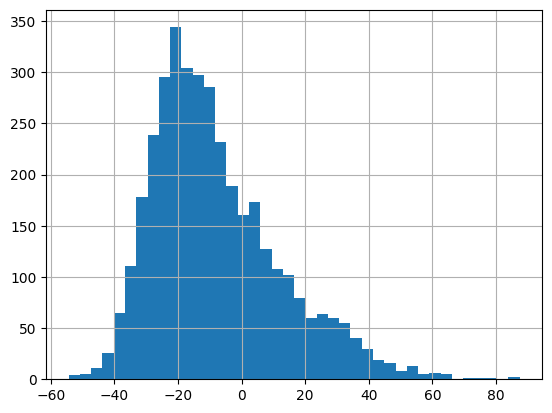

In [67]:
sdf['quality'].hist(bins = 40)

## defense

In [ ]:
# #the scores of the opponents in an alliance

def opp_scores(team_num, game_key):
    scores = []
    opps = df.loc[(df['key'] == game_key) & (df['alliance'] != df.loc[(df['key'] == game_key) & (df['team_number'] == team_num), 'alliance'].iloc[0])]
    # display(opps)
    for index, team in opps.iterrows():
        coralsWithDefense = team['teleopCoralCount']
        coralsWithoutDefense = (sdf.at[team['team_number'], 'teleopReef_tba_botRowCount'] + 
                                sdf.at[team['team_number'], 'teleopReef_tba_midRowCount'] +
                                sdf.at[team['team_number'], 'teleopReef_tba_topRowCount'] +
                                sdf.at[team['team_number'], 'teleopReef_trough'])
        
        scores.append(coralsWithoutDefense - coralsWithDefense)
    return sum(scores)/len(scores)


In [114]:
#the average score of all opponents of team
def opp_team_games(team_num):
    game_keys = df.loc[df['team_number'] == team_num]['key']
    averages = []
    for i in game_keys:
        averages.append(opp_scores(team_num, i))
    
    return sum(averages)/len(averages)

In [112]:
opp_scores('frc2231','2025isde4_qm36')

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
63683,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,True,True,True,1.0,0.0,frc4320,114.0,1,blue
83080,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,True,True,True,1.0,0.0,frc1954,114.0,2,blue
102477,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,True,True,True,1.0,0.0,frc5291,114.0,3,blue


[np.float64(2.2448979591836746),
 np.float64(-4.111111111111111),
 np.float64(-2.9629629629629655)]

In [111]:
df.loc[df['key'] == '2025isde4_qm36']

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
5492,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,False,False,True,2.0,0.0,frc1577,127.0,1,red
24889,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,False,False,True,2.0,0.0,frc2231,127.0,2,red
44286,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,False,False,True,2.0,0.0,frc6738,127.0,3,red
63683,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,True,True,True,1.0,0.0,frc4320,114.0,1,blue
83080,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,True,True,True,1.0,0.0,frc1954,114.0,2,blue
102477,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,True,True,True,1.0,0.0,frc5291,114.0,3,blue


In [119]:
opp_team_games('frc2679')

np.float64(5.4135388290957405)

In [123]:
opp_team_games('frc7067')

np.float64(4.3488308610217805)

In [126]:
opp_team_games('frc1937')

np.float64(3.3896184795960163)

In [146]:
opp_team_games('frc1580')

np.float64(4.729591156943446)

## the two other columns

<Axes: >

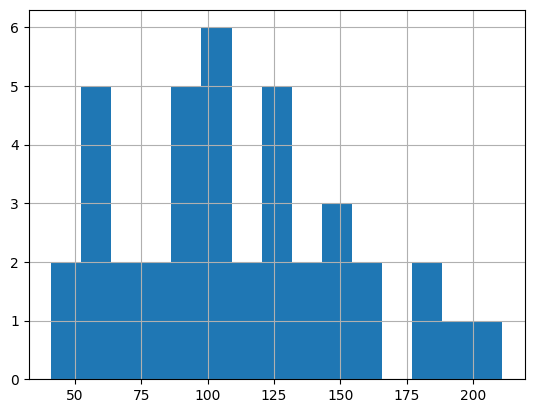

In [164]:
df.loc[df['team_number'] == 'frc3211']['score'].hist(bins=15)

In [161]:
df.loc[df['team_number'] == 'frc3211']['score'].kurt()

np.float64(-0.3421938767674644)

In [162]:
df.loc[df['team_number'] == 'frc3211']['score'].skew()

np.float64(0.4319133416291086)

In [167]:
df['team_number'].unique()

array(['frc2783', 'frc5045', 'frc538', ..., 'frc4972', 'frc8500',
       'frc5019'], shape=(3722,), dtype=object)

## task 49

In [ ]:
def iqr_outliers (team):
    data = df.loc[df['team_number'] == team]

    Q1 = data['score'].quantile(0.25)
    Q3 = data['score'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # 5. Identify outliers
    # Outliers are data points outside the lower and upper bounds
    outliers = data[(data['score'] < lower) | (data['score'] > upper)]
    outliers

    # # 6. Filter the DataFrame to remove outliers (keep only non-outliers)
    # df_filtered = df[(df['values'] >= lower) & (df['values'] <= upper)]
    # print("\nDataFrame after removing outliers:")
    # print(df_filtered)